---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 7. Параметри синусоїдного струму. Потужність і резонанс</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Миттєве, амплітудне, середнє та діюче значення. Початкова фаза і кутова частота</li>
  <li>Потужності в колах змінного струму</li>
  <li>Резонанс у колах змінного струму. Коливальний контур</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 7 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Миттєве, амплітудне, середнє та діюче значення. Початкова фаза і кутова частота](#ac-values)
* [Потужності в колах змінного струму](#ac-power)
* [Резонанс у колах змінного струму. Коливальний контур](#resonance)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Миттєве, амплітудне, середнє та діюче значення. Початкова фаза і кутова частота <a class="anchor" id="ac-values"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Записувати синусоїдну величину через амплітуду, кутову частоту та початкову фазу
> - Розрізняти миттєве, амплітудне, середнє і діюче значення
> - Обчислювати діюче (середньоквадратичне) значення синусоїдного струму й напруги
> - Пояснювати, чому побутові прилади показують саме діюче значення

</div>

### Параметри синусоїдної величини

$$u(t) = U_m \sin(\omega t + \varphi_u), \qquad i(t) = I_m \sin(\omega t + \varphi_i)$$

| Величина | Позначення | Зміст |
|----------|-----------|-------|
| Миттєве значення | $u(t)$, $i(t)$ | Значення в конкретний момент часу $t$ |
| Амплітудне (максимальне) значення | $U_m$, $I_m$ | Найбільше за модулем значення за період |
| Кутова частота | $\omega = 2\pi f = 2\pi/T$, рад/с | Швидкість зміни фази |
| Початкова фаза | $\varphi_u$, $\varphi_i$ | Значення фази в момент $t=0$ |
| Різниця фаз (зсув) | $\varphi = \varphi_u - \varphi_i$ | Визначає характер навантаження (активне/індуктивне/ємнісне) |

### Середнє та діюче значення

**Середнє за період значення** синусоїди дорівнює нулю (додатна і від'ємна півхвилі однакові за площею), тому на практиці використовують **середньовипрямлене** значення (середнє за півперіод, те що показує випрямляч):

$$U_{ср} = \dfrac{1}{T/2}\int_0^{T/2} U_m\sin(\omega t)\,dt = \dfrac{2}{\pi}U_m \approx 0{,}637\,U_m$$

**Діюче (середньоквадратичне, RMS) значення** визначається за тепловою дією струму — це значення сталого струму, що виділяє на активному опорі за період ту саму енергію, що й змінний струм:

$$U = \sqrt{\dfrac{1}{T}\int_0^T u^2(t)\,dt} = \dfrac{U_m}{\sqrt2} \approx 0{,}707\,U_m$$

Коефіцієнт форми синусоїди: $k_ф = U/U_{ср} = \dfrac{\pi}{2\sqrt2} \approx 1{,}11$.

> **Саме діюче значення** вказують на шильдиках приладів і показують мультиметри в режимі AC: побутова мережа «220 В» — це діюче значення, амплітудне при цьому $U_m = 220\sqrt2 \approx 311$ В.


Побудуємо синусоїду напруги мережі та позначимо на графіку її амплітудне, середньовипрямлене і діюче значення:

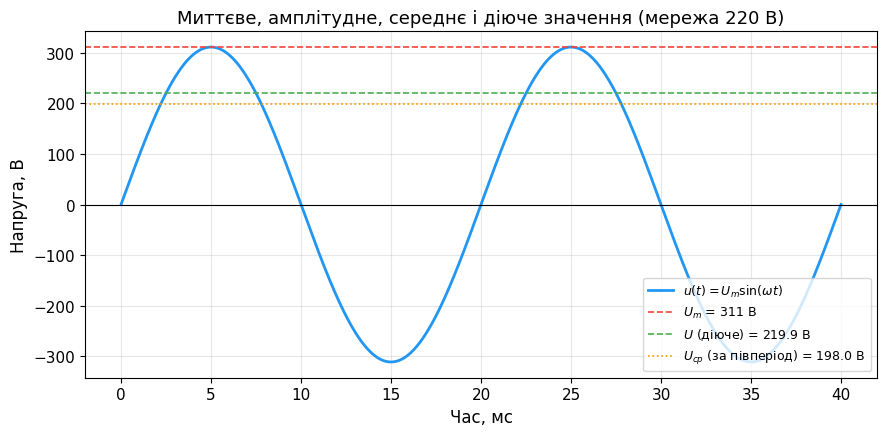

Um=311.0 В, U(діюче)=219.91 В, Uср(півперіод)=197.99 В, kф=1.111


In [2]:
# Ілюстрація: миттєве, амплітудне, середньовипрямлене і діюче значення синусоїди
Um = 311.0
f0 = 50.0
w0 = 2*np.pi*f0
t = np.linspace(0, 2/f0, 1000)
u = Um*np.sin(w0*t)

U_rms = Um/np.sqrt(2)
U_avg = 2*Um/np.pi

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t*1e3, u, color='#2196F3', lw=2, label='$u(t)=U_m\\sin(\\omega t)$')
ax.axhline(Um, color='#F44336', ls='--', lw=1.2, label=f'$U_m$ = {Um:.0f} В')
ax.axhline(U_rms, color='#4CAF50', ls='--', lw=1.2, label=f'$U$ (діюче) = {U_rms:.1f} В')
ax.axhline(U_avg, color='#FF9800', ls=':', lw=1.2, label=f'$U_{{ср}}$ (за півперіод) = {U_avg:.1f} В')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Час, мс'); ax.set_ylabel('Напруга, В')
ax.set_title('Миттєве, амплітудне, середнє і діюче значення (мережа 220 В)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Um={Um:.1f} В, U(діюче)={U_rms:.2f} В, Uср(півперіод)={U_avg:.2f} В, kф={U_rms/U_avg:.3f}')


---
### ⚡ Практичне застосування: Діюче значення

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

- **Мультиметри** у режимі змінного струму зазвичай показують саме діюче значення (частина недорогих приладів — "average sensing, RMS calibrated", коректне лише для чистої синусоїди; для спотвореного сигналу потрібен **True RMS**-прилад).
- **Розрахунок потужності на резисторі** коректний лише через діюче значення: $P = U I \cos\varphi = I^2 R$ (з $I$ — діюче).
- **Ізоляція та запобіжники** розраховують за амплітудним значенням напруги/струму (пікові навантаження), а теплові розрахунки (нагрів провідників) — за діючим.

</div>

---
### ✅ Питання для самоперевірки: Миттєве, амплітудне, середнє, діюче значення

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому середнє за повний період значення синусоїди дорівнює нулю, а середньовипрямлене — ні?</summary>

> **Відповідь:** За повний період додатна і від'ємна півхвилі синусоїди симетричні й однакові за площею, тому інтеграл (а отже й середнє) дорівнює нулю. Середньовипрямлене значення обчислюють від модуля сигналу (або за один півперіод), тому воно завжди додатне: $U_{ср}=2U_m/\pi$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому для теплових розрахунків використовують саме діюче значення?</summary>

> **Відповідь:** Діюче значення визначене так, щоб виділена на резисторі теплова енергія за період змінного струму дорівнювала енергії від сталого струму такої ж (діючої) величини: $\int_0^T i^2 R\,dt = I^2 R T$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Мультиметр показує 220 В (AC). Яке амплітудне значення напруги в мережі?</summary>

> **Відповідь:** $U_m = U\sqrt2 = 220 \cdot 1{,}414 \approx 311$ В.

</details>

---
### 📝 Задачі для самостійного розв'язання: Миттєве, середнє та діюче значення


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Напруга мережі $u(t) = 311\sin(314t + 30°)$ В. Визначте амплітуду, діюче та середнє (середньовипрямлене) значення, частоту, період, початкову фазу і миттєве значення при $t = 0$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_m = 311$ В; $U = U_m/\sqrt2 \approx 220$ В; $U_{сер} = 2U_m/\pi \approx 198$ В; $f = 314/2\pi \approx 50$ Гц; $T = 20$ мс; $\psi = 30°$; $u(0) = 311\sin30° \approx 155{,}5$ В.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Порівняйте діючі значення сигналів однакової амплітуди $10$ В: меандру (±10 В), синусоїди та симетричного трикутного сигналу.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Меандр: $10$ В; синусоїда: $10/\sqrt2 \approx 7{,}07$ В; трикутник: $10/\sqrt3 \approx 5{,}77$ В. Чим «гостріша» форма, тим менше діюче значення за тієї ж амплітуди.

</details>

---

## Потужності в колах змінного струму <a class="anchor" id="ac-power"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Розрізняти активну, реактивну та повну потужність
> - Обчислювати потужності через комплексну (символічну) форму $\bar S = \dot U \dot I^*$
> - Пояснювати фізичний зміст коефіцієнта потужності $\cos\varphi$
> - Будувати трикутник потужностей

</div>

### Миттєва, активна, реактивна та повна потужність

Нехай $u(t)=U_m\sin(\omega t)$, $i(t)=I_m\sin(\omega t-\varphi)$ ($\varphi$ — кут зсуву фаз між напругою і струмом, що вносить навантаження). Миттєва потужність:

$$p(t) = u(t)i(t) = UI\cos\varphi\,\bigl(1-\cos2\omega t\bigr) + UI\sin\varphi\sin2\omega t$$

Вона містить сталу складову й складову, що коливається з подвоєною частотою. З цього виділяють:

| Потужність | Формула | Одиниці | Фізичний зміст |
|-----------|---------|---------|----------------|
| **Активна** $P$ | $P = UI\cos\varphi$ | Вт | Середня за період, безповоротно перетворюється в тепло/роботу (на $R$) |
| **Реактивна** $Q$ | $Q = UI\sin\varphi$ | вар | Амплітуда «коливальної» частини — енергія, що перетікає між джерелом і полем $L$, $C$, не витрачаючись |
| **Повна (уявна)** $S$ | $S = UI = \sqrt{P^2+Q^2}$ | В·А | Добуток діючих значень, характеризує повне навантаження джерела |
| **Коефіцієнт потужності** | $\cos\varphi = P/S$ | — | Частка потужності, що йде на корисну роботу |

### Комплексна (повна) потужність

У символічному методі зручно використовувати комплексну потужність $\bar S = \dot U \dot I^{*}$ (де $\dot I^{*}$ — спряжений комплекс струму):

$$\bar S = \dot U \dot I^{*} = P + jQ, \qquad S=|\bar S|,\quad \varphi = \arg(\bar S) = \arg Z$$

Для окремих елементів: резистор споживає лише активну потужність ($Q_R=0$), ідеальна котушка й конденсатор — лише реактивну, причому з протилежними знаками ($Q_L=I^2\omega L>0$, $Q_C=-I^2/(\omega C)<0$), тому в контурі вони частково компенсують одна одну.


Побудуємо трикутник потужностей ($P$, $Q$, $S$) для кола з активним і реактивним навантаженням:

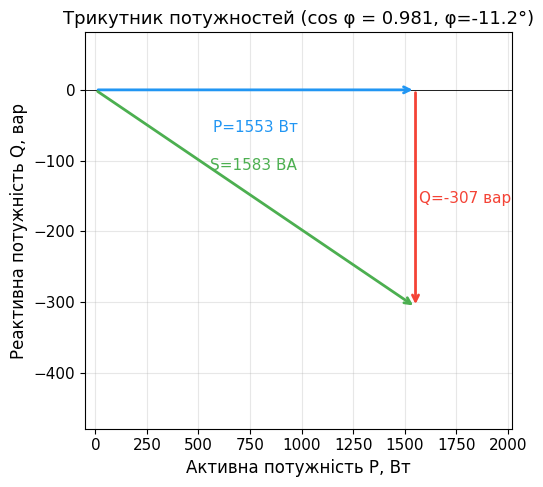

Z = 30.00-5.93j Ом | I = 7.194 А | P = 1552.7 Вт | Q = -306.8 вар | S = 1582.7 ВА | cosφ = 0.981


In [3]:
# Трикутник потужностей для RLC-навантаження
U_s, f_s2 = 220.0, 50.0
w_s2 = 2*np.pi*f_s2
R_s2, L_s2, C_s2 = 30.0, 0.15, 60e-6

Z = R_s2 + 1j*(w_s2*L_s2 - 1/(w_s2*C_s2))
I_s2 = U_s / Z
phi = np.angle(Z)
S_complex = U_s * np.conj(I_s2)
P, Q = S_complex.real, S_complex.imag
S = abs(S_complex)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.annotate('', xy=(P, 0), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2))
ax.annotate('', xy=(P, Q), xytext=(P, 0), arrowprops=dict(arrowstyle='->', color='#F44336', lw=2))
ax.annotate('', xy=(P, Q), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2))
ax.text(P/2, -60, f'P={P:.0f} Вт', color='#2196F3', ha='center')
ax.text(P+15, Q/2, f'Q={Q:.0f} вар', color='#F44336', va='center')
ax.text(P/2-10, Q/2+40, f'S={S:.0f} ВА', color='#4CAF50', ha='center')
ax.set_xlim(-50, max(P, 1)*1.3); ax.set_ylim(min(Q,0)*1.3-80, max(Q,1)*1.3+80)
ax.set_xlabel('Активна потужність P, Вт'); ax.set_ylabel('Реактивна потужність Q, вар')
ax.set_title(f'Трикутник потужностей (cos φ = {np.cos(phi):.3f}, φ={np.degrees(phi):.1f}°)')
ax.axhline(0, color='k', lw=0.6); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Z = {Z:.2f} Ом | I = {abs(I_s2):.3f} А | P = {P:.1f} Вт | Q = {Q:.1f} вар | S = {S:.1f} ВА | cosφ = {np.cos(phi):.3f}')


---
### ⚡ Практичне застосування: Потужності та коефіцієнт потужності

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

- **Компенсація реактивної потужності**: промислові підприємства з великою індуктивною навантаженістю (двигуни, трансформатори) встановлюють батареї конденсаторів, щоб підняти $\cos\varphi$ ближче до 1 — це зменшує струм у лінії при тій самій активній потужності й знижує втрати на нагрів проводів.
        - **Тарифікація електроенергії** для промислових споживачів враховує не лише активну (кВт·год), а і реактивну складову — низький $\cos\varphi$ штрафується.
- **Блоки живлення з корекцією коефіцієнта потужності (PFC)** формують вхідний струм майже синфазним з напругою мережі, наближуючи $\cos\varphi \to 1$.

</div>

---
### ✅ Питання для самоперевірки: Потужності в колах змінного струму

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому реактивна потужність не виконує корисної роботи, але враховується при виборі проводів і джерела живлення?</summary>

> **Відповідь:** Реактивна потужність відповідає енергії, яка лише почергово накопичується в полі $L$/$C$ і повертається назад у джерело — в середньому за період корисна робота не виконується. Проте відповідний струм реально протікає провідниками й навантажує джерело, викликаючи додаткові теплові втрати на активних опорах лінії, тому його не можна ігнорувати.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Навантаження має $P=800$ Вт, $Q=600$ вар. Чому дорівнює S і cosφ?</summary>

> **Відповідь:** $S=\sqrt{800^2+600^2}=1000$ В·А, $\cos\varphi = P/S = 0{,}8$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому в ідеальному конденсаторі й ідеальній котушці немає активної потужності?</summary>

> **Відповідь:** Струм і напруга на них зсунуті рівно на $90°$ ($\varphi=\pm90°$), тому $\cos\varphi=0$ і $P=UI\cos\varphi=0$ — вся енергія лише циркулює між джерелом і полем елемента.

</details>

---
### 📝 Задачі для самостійного розв'язання: Потужності в колах змінного струму


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Споживач живиться від мережі $U = 220$ В, $f = 50$ Гц, струм $I = 5$ А, $\cos\varphi = 0{,}8$ (індуктивний характер). Знайдіть $S$, $P$, $Q$ та ємність конденсатора, який треба ввімкнути паралельно для повної компенсації реактивної потужності.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $S = 1100$ В·А, $P = 880$ Вт, $Q = S\sin\varphi = 660$ вар. $C = \dfrac{Q}{\omega U^2} = \dfrac{660}{314{,}16\cdot 220^2} \approx 43{,}4$ мкФ.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Навантаження $\underline Z = 8 + j6$ Ом підключено до напруги $U = 100$ В. Знайдіть комплексну потужність.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I = 100/10 = 10$ А; $\underline S = I^2\underline Z = 800 + j600$ В·А: $P = 800$ Вт, $Q = 600$ вар, $S = 1000$ В·А, $\cos\varphi = 0{,}8$.

</details>

---

## Резонанс у колах змінного струму. Коливальний контур <a class="anchor" id="resonance"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Формулювати умову резонансу для послідовного і паралельного кіл
> - Обчислювати резонансну частоту та добротність контуру
> - Розрізняти резонанс напруг і резонанс струмів за характером кола, в якому вони виникають
> - Пояснювати смугу пропускання коливального контуру через добротність

</div>

### Коливальний контур і умова резонансу

**Коливальний контур** — коло з котушки індуктивності та конденсатора, здатне обмінюватися енергією між магнітним полем $L$ і електричним полем $C$. **Резонанс** — режим кола, в якому реактивна складова повного опору (для послідовного кола) або повної провідності (для паралельного кола) дорівнює нулю, тобто вхідні напруга і струм джерела збігаються за фазою ($\varphi=0$, $\cos\varphi=1$):

$$\omega_0 = \dfrac{1}{\sqrt{LC}}, \qquad f_0 = \dfrac{1}{2\pi\sqrt{LC}}$$

Резонансна частота в обох випадках (послідовний і паралельний ідеальний контур) обчислюється за однією формулою — відрізняється лише поведінка струму й опору при резонансі.

### Резонанс напруг (послідовний $RLC$-контур)

Виникає в **послідовному** з'єднанні $R$, $L$, $C$. При резонансі $X_L=X_C$, реактивні опори компенсують одне одного, і повний опір мінімальний та чисто активний: $Z=R$. Струм у контурі максимальний: $I_{max}=E/R$.

$$U_L = U_C = Q\cdot E, \qquad Q = \dfrac{\omega_0 L}{R} = \dfrac{1}{\omega_0 R C} = \dfrac{1}{R}\sqrt{\dfrac{L}{C}}$$

При високій добротності ($Q\gg1$) напруги на $L$ і $C$ можуть у десятки разів перевищувати напругу джерела — звідси назва «резонанс напруг».

### Резонанс струмів (паралельний $RLC$-контур)

Виникає в **паралельному** з'єднанні віток $L$ і $C$ (класичний коливальний, «tank»-контур). При резонансі реактивні провідності віток компенсуються, повна провідність кола мінімальна (опір — максимальний, чисто активний), тому струм, що споживається **від джерела**, мінімальний. Водночас між $L$ і $C$ всередині контуру циркулює великий **контурний** струм:

$$I_{L} = I_{C} = Q \cdot I, \qquad Q = \dfrac{R}{\omega_0 L} = \omega_0 R C = R\sqrt{\dfrac{C}{L}} \quad \text{(для ідеального контуру з паралельним } R)$$

### Смуга пропускання

Добротність визначає вибірковість (гостроту) резонансної кривої: смуга пропускання на рівні $0{,}707$ від максимуму (−3 дБ) дорівнює

$$\Delta f = \dfrac{f_0}{Q}$$


Побудуємо універсальну резонансну криву послідовного контуру для кількох значень добротності $Q$: чим вища $Q$, тим вужча крива.

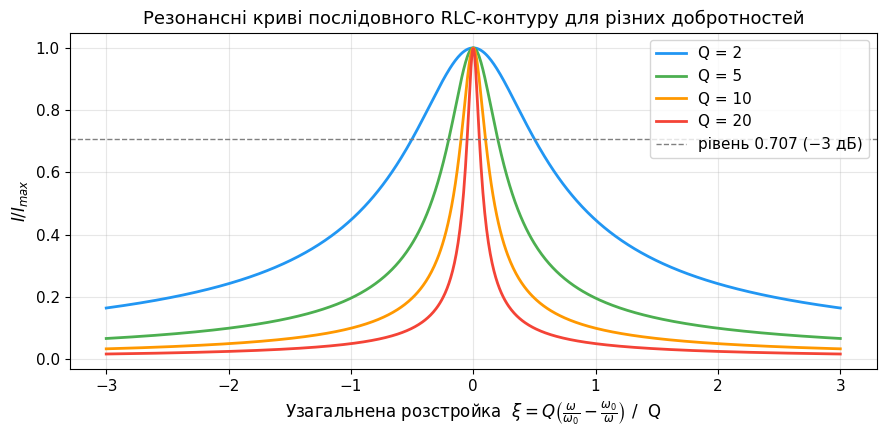

Чим вище Q, тим вужча й гостріша резонансна крива (вища вибірковість контуру).


In [4]:
# Універсальна резонансна крива I(ω)/I0 для послідовного RLC при різних Q
w0_n = 1.0
detuning = np.linspace(-3, 3, 800)                 # (ω/ω0 - ω0/ω) ~ розстроювання
fig, ax = plt.subplots(figsize=(9, 4.5))
for Qv, color in [(2, '#2196F3'), (5, '#4CAF50'), (10, '#FF9800'), (20, '#F44336')]:
    resp = 1 / np.sqrt(1 + (Qv*detuning)**2)
    ax.plot(detuning, resp, color=color, lw=2, label=f'Q = {Qv}')
ax.axhline(1/np.sqrt(2), color='gray', ls='--', lw=1, label='рівень 0.707 (−3 дБ)')
ax.set_xlabel(r'Узагальнена розстройка  $\xi = Q\left(\frac{\omega}{\omega_0}-\frac{\omega_0}{\omega}\right)$ /  Q')
ax.set_ylabel('$I/I_{max}$')
ax.set_title('Резонансні криві послідовного RLC-контуру для різних добротностей')
ax.legend(); plt.tight_layout(); plt.show()
print('Чим вище Q, тим вужча й гостріша резонансна крива (вища вибірковість контуру).')


---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Не плутайте, який контур («послідовний» чи «паралельний») дає резонанс напруг, а який — резонанс струмів.** Резонанс напруг — завжди про **послідовне** з'єднання $R,L,C$ (напруги на $L$ і $C$ зростають у $Q$ разів). Резонанс струмів — завжди про **паралельне** з'єднання віток $L$ і $C$ (контурний струм між $L$ і $C$ зростає у $Q$ разів, а струм від джерела — мінімальний). Формула резонансної частоти $\omega_0=1/\sqrt{LC}$ в обох випадках однакова — плутанина виникає саме в тому, що зростає (напруга чи струм) і що мінімізується (опір чи провідність).

</div>

---
### ⚡ Практичне застосування: Резонанс і коливальні контури

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Застосування | Тип резонансу |
|--------------|---------------|
| **Вхідний контур радіоприймача (селекція станції)** | Резонанс струмів (паралельний контур) — виділяє потрібну частоту з великим опором на резонансі |
| **Смуговий фільтр ПЧ, контур гетеродина** | Резонанс напруг або струмів залежно від схеми включення |
| **Індукційна плита, бездротова зарядка** | Резонанс напруг у послідовному контурі підвищує ККД передачі енергії |
| **Захист від перенапруги через резонанс** | У силових мережах паразитний резонанс напруг може створювати небезпечні перенапруги на елементах — це враховують при проєктуванні фільтрів |

</div>

---
### ✅ Питання для самоперевірки: Резонанс у колах змінного струму

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Контур має L=200 мкГн, C=200 пФ. Яка резонансна частота?</summary>

> **Відповідь:** $f_0 = \dfrac{1}{2\pi\sqrt{LC}} = \dfrac{1}{2\pi\sqrt{200\cdot10^{-6}\cdot200\cdot10^{-12}}} \approx 796$ кГц.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому при резонансі струмів струм від джерела мінімальний, хоча в самому контурі струми великі?</summary>

> **Відповідь:** Струми $I_L$ і $I_C$ у вітках рівні за модулем і протилежні за фазою (зсунуті на 180°), тому в вузлі вони практично компенсують одна одну — джерелу залишається лише «доповнювати» невеликі втрати в активному опорі, а основна енергія циркулює між $L$ і $C$ всередині контуру.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Послідовний контур має Q=100 при f0=1 МГц. Яка смуга пропускання?</summary>

> **Відповідь:** $\Delta f = f_0/Q = 1\,000\,000/100 = 10$ кГц.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Що відбувається з $U_L$ і $U_C$ при резонансі напруг, якщо Q=50?</summary>

> **Відповідь:** $U_L=U_C=Q\cdot E = 50E$ — напруги на реактивних елементах у 50 разів перевищують напругу джерела (компенсуючи одна одну за фазою так, що на вході залишається лише $U_R=E$).

</details>

---
### 📝 Задачі для самостійного розв'язання: Резонанс


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Послідовний контур: $L = 100$ мкГн, $C = 100$ пФ, $R = 10$ Ом, напруга джерела $U = 1$ мВ. Знайдіть резонансну частоту, характеристичний опір, добротність, смугу пропускання та напругу на конденсаторі при резонансі.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $f_0 = \dfrac{1}{2\pi\sqrt{LC}} \approx 1{,}59$ МГц; $\rho = \sqrt{L/C} = 1000$ Ом; $Q = \rho/R = 100$; $2\Delta f = f_0/Q \approx 15{,}9$ кГц; $U_C = QU = 100$ мВ.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Вхідний контур радіоприймача СХ-діапазону (531–1602 кГц) має $L = 200$ мкГн. У яких межах має змінюватися ємність конденсатора змінної ємності?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $C = \dfrac{1}{(2\pi f)^2L}$: на 531 кГц — $\approx 449$ пФ, на 1602 кГц — $\approx 49{,}3$ пФ. Отже, $C \approx 49\ldots449$ пФ (перекриття за частотою в 3 рази вимагає перекриття за ємністю в 9 разів).

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 6. Символічний метод розрахунку кіл синусоїдного струму](Тема_06_Символічний_метод.ipynb) &nbsp;|&nbsp; [Тема 8. Зв'язані коливальні контури. Чотириполюсники](Тема_08_Взаємна_індуктивність_та_чотириполюсники.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
